### Checking if files suffered any transformation wrt single/dual tar gz

#### Number of files

In [ ]:
import os

# Define the directory path
dir_path = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/all_pcls_original'

# Check if the directory exists
if os.path.exists(dir_path):
    # Get the list of files in the directory
    file_count = len([f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f))])
    print(f"Total number of .pcl files I used: {file_count}")
else:
    print(f"The directory {dir_path} does not exist.")


# Define the directory path
dir_path2 = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted'

# Check if the directory exists
if os.path.exists(dir_path2):
    # Initialize a counter for the pcl files
    pcl_file_count = 0

    # Walk through the directory and its subdirectories
    for root, dirs, files in os.walk(dir_path2):
        # Count .pcl files in each directory
        pcl_file_count += len([f for f in files if f.endswith('.pcl')])

    print(f"Total number of .pcl files in the single channel folders: {pcl_file_count}")
else:
    print(f"The directory {dir_path2} does not exist.")

# Define the directory path
dir_path3 = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/dual_channel_extracted'
# Check if the directory exists
if os.path.exists(dir_path3):
    # Initialize a counter for the pcl files
    pcl_file_count = 0

    # Walk through the directory and its subdirectories
    for root, dirs, files in os.walk(dir_path3):
        # Count .pcl files in each directory
        pcl_file_count += len([f for f in files if f.endswith('.pcl')])

    print(f"Total number of .pcl files in the dual channel folders: {pcl_file_count}")
else:
    print(f"The directory {dir_path3} does not exist.")

# Define the directory path
dir_path4 = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/all_spell_extracted'
# Check if the directory exists
if os.path.exists(dir_path4):
    # Initialize a counter for the pcl files
    pcl_file_count = 0

    # Walk through the directory and its subdirectories
    for root, dirs, files in os.walk(dir_path4):
        # Count .pcl files in each directory
        pcl_file_count += len([f for f in files if f.endswith('.pcl')])

    print(f"Total number of .pcl files in all_spell_datasets: {pcl_file_count}")
else:
    print(f"The directory {dir_path4} does not exist.")

#### Duplicate files

In [ ]:
import os
from collections import defaultdict

# Define the directory path
dir_path4 = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/all_extracted'

# Dictionary to store pcl filenames and their occurrences
pcl_files = defaultdict(list)

# Check if the directory exists
if os.path.exists(dir_path4):
    # Walk through the directory and its subdirectories
    for root, dirs, files in os.walk(dir_path4):
        for f in files:
            if f.endswith('.pcl'):
                pcl_files[f].append(os.path.join(root, f))  # Store full path of each occurrence
else:
    print(f"The directory {dir_path4} does not exist.")

# Find duplicate files (files that appear more than once)
duplicates = {fname: paths for fname, paths in pcl_files.items() if len(paths) > 1}

# Print results
if duplicates:
    print(f"Found {len(duplicates)} duplicate .pcl filenames:")
    for fname, paths in duplicates.items():
        print(f"\nDuplicate: {fname}")
        for path in paths:
            print(f" - {path}")
else:
    print("No duplicate .pcl filenames found.")

#### Number of files in the intersections

In [ ]:
import os
from itertools import combinations

# Define the directory paths
directories = {
    "all_pcls_original": "/home/logs/jtorresb/yeastformer/yeast/yeast_data/all_pcls_original",
    "single_channel_extracted": "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted",
    "dual_channel_extracted": "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/dual_channel_extracted",
    "all_spell_extracted": "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/all_spell_extracted"
}

# Function to collect all .pcl filenames in a directory
def get_pcl_filenames(dir_path, nested=True):
    pcl_files = set()
    if os.path.exists(dir_path):
        if nested:  # If the directory contains subfolders
            for root, _, files in os.walk(dir_path):
                pcl_files.update({f for f in files if f.endswith('.pcl')})
        else:  # If the directory directly contains .pcl files
            pcl_files.update({f for f in os.listdir(dir_path) if f.endswith('.pcl')})
    return pcl_files

# Collect filenames from each directory
pcl_files_dict = {
    "all_pcls_original": get_pcl_filenames(directories["all_pcls_original"], nested=False),
    "single_channel_extracted": get_pcl_filenames(directories["single_channel_extracted"], nested=True),
    "dual_channel_extracted": get_pcl_filenames(directories["dual_channel_extracted"], nested=True),
    "all_spell_extracted": get_pcl_filenames(directories["all_spell_extracted"], nested=True),
}

# Compute pairwise intersections
for (name1, files1), (name2, files2) in combinations(pcl_files_dict.items(), 2):
    intersection = files1.intersection(files2)
    print(f"Intersection between {name1} and {name2}: {len(intersection)} common .pcl files")

# Total number of .pcl files all_original: 556
# Total number of .pcl files in the single channel folders: 336
# Total number of .pcl files in the dual channel folders: 448
# Total number of .pcl files in all_spell_datasets: 738


#### Missing/Matching

In [ ]:
import os
import filecmp

# Define the directory paths
single_dir = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_extracted'
all_dir = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/all_spell_extracted'

def get_pcl_files(dir_path):
    """
    Walk through the directory (including subdirectories) and return a dictionary
    mapping each .pcl filename to its full path (the first occurrence found).
    """
    pcl_files = {}
    for root, dirs, files in os.walk(dir_path):
        for f in files:
            if f.endswith('.pcl'):
                # If a file with this name hasn't been recorded, add it.
                if f not in pcl_files:
                    pcl_files[f] = os.path.join(root, f)
                # If there are duplicates within a folder, you can decide how to handle them.
    return pcl_files

# Get .pcl files from both directories
single_pcl = get_pcl_files(single_dir)
all_pcl = get_pcl_files(all_dir)

# Find missing files: those that are in the single channel folder but not in all_extracted
missing_files = set(single_pcl.keys()) - set(all_pcl.keys())
print(f"Number of missing .pcl files (in all_extracted): {len(missing_files)}")
if missing_files:
    print("Missing files:")
    for f in missing_files:
        print(f" - {f}")

# For common files, compare their contents using filecmp (deep comparison)
common_files = set(single_pcl.keys()).intersection(set(all_pcl.keys()))
identical_count = 0
for f in common_files:
    single_file_path = single_pcl[f]
    all_file_path = all_pcl[f]
    if filecmp.cmp(single_file_path, all_file_path, shallow=False):
        identical_count += 1

print(f"Number of common .pcl files with identical contents: {identical_count}")

### Negative Values

#### Overview

In [ ]:
import os
import pandas as pd

# Define the root directory where the subfolders are located
root_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/dual_channel_extracted"

total_columns = 0
columns_with_negatives = 0
columns_with_zero_negatives = 0
negative_counts = []

# Collect all pcl file paths
pcl_files = []

for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith(".pcl"):
            pcl_files.append(os.path.join(root, file))

pcl_count = len(pcl_files)
print(f"Found {pcl_count} PCL files. Processing...")

# Process each PCL file
for file_path in pcl_files:
    try:
        df = pd.read_csv(file_path, sep="\t", index_col=0, header=0)

        # Convert all columns to numeric values, coercing errors to NaN
        df = df.apply(pd.to_numeric, errors='coerce')

        # Count total columns
        total_columns += df.shape[1]

        # Count columns that have at least one negative value
        negative_per_column = (df < 0).sum()

        # Count columns with at least 1 negative value
        columns_with_negatives += (negative_per_column > 0).sum()

        # Count columns with 0 negative values
        columns_with_zero_negatives += (negative_per_column == 0).sum()

        # Collect the negative counts for columns that contain at least 1 negative value
        negative_counts.extend(negative_per_column[negative_per_column > 0].values)

    except Exception as e:
        print(f"\nError reading {file_path}: {e}")

# Calculate the average negative values in columns that have at least 1 negative value
if columns_with_negatives > 0:
    average_negative_values = sum(negative_counts) / len(negative_counts)
else:
    average_negative_values = 0

# Final results
print("\nTotal number of columns across all PCL files:", total_columns)
print("Total number of columns with at least one negative value:", columns_with_negatives)
print("Total number of columns with zero negative values:", columns_with_zero_negatives)
print("Average number of negative values per column (for columns with at least 1 negative value):", average_negative_values)

### Checking expression distribution for a specific gene using dual-channel data

In [ ]:
import pickle

with open('/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl', 'rb') as f:
    hk_genes = pickle.load(f)

print(hk_genes)

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the root directory and the gene of interest
root_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/dual_channel_extracted"
gene = "YFL039C"

# Initialize a list to store all expression values for the gene
expression_values = []

# Traverse the root directory
for subfolder in os.listdir(root_dir):
    subfolder_path = os.path.join(root_dir, subfolder)
    
    if os.path.isdir(subfolder_path):
        # Loop through each .pcl file in the subfolder
        for file_name in os.listdir(subfolder_path):
            if file_name.endswith(".pcl"):
                file_path = os.path.join(subfolder_path, file_name)
                
                try:
                    # Read .pcl file as a DataFrame (assuming tab-separated with gene names as index)
                    df = pd.read_csv(file_path, sep='\t', index_col=0)

                    # If gene is present, store its expression values (excluding NaN)
                    if gene in df.index:
                        values = df.loc[gene].dropna().values.flatten()  # Drop missing values
                        expression_values.extend(values)
                
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")

                    
expression_values = np.array([float(x) for x in expression_values if isinstance(x, (int, float))])


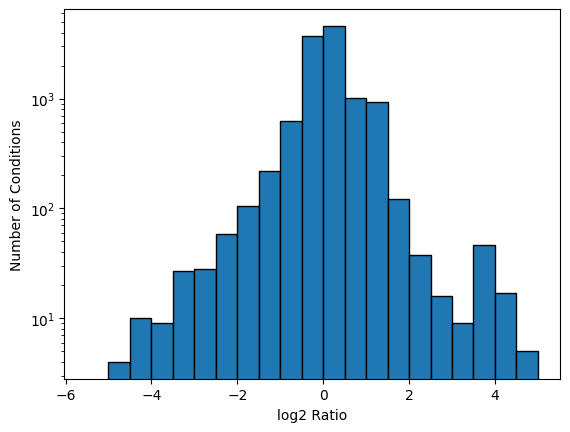

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Define bin edges from -5 to 5 with 0.5 increments
bins = np.arange(-5.5, 5.5, 0.5) 

# Create histogram
plt.hist(expression_values, bins=bins, edgecolor="black")

# Set axis labels
plt.yscale("log")
plt.xlabel("log2 Ratio")
plt.ylabel("Number of Conditions")

# Show plot
plt.show()

### Understanding Preprocessing

In [ ]:
import os
import pandas as pd

# Directory containing subfolders with .pcl files
root_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted"

total_files = 0
wt_files = 0
first_wt_file = None

# Walk through all subfolders in root_dir
for dirpath, _, filenames in os.walk(root_dir):
    for filename in filenames:
        if filename.endswith(".pcl"):
            total_files += 1
            file_path = os.path.join(dirpath, filename)
            try:
                # Read the .pcl file as a DataFrame (assuming tab-delimited)
                df = pd.read_csv(file_path, sep="\t", index_col=0, low_memory=False)
                
                # Extract column names
                columns = df.columns
                
                # Check if any column contains "wt" (case-insensitive)
                if any("wt" in col.lower() for col in columns):
                    wt_files += 1
                    if first_wt_file is None:
                        first_wt_file = file_path
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

if total_files > 0:
    percentage = (wt_files / total_files) * 100
    print(f"Total .pcl files: {total_files}")
    print(f".pcl files with a WT column: {wt_files} ({percentage:.2f}%)")
    if first_wt_file:
        print(f"First file containing WT column: {first_wt_file}")
        print("Columns in the first WT-containing file:")
        print(pd.read_csv(first_wt_file, sep="\t", index_col=0, nrows=0).columns)  # Print column names only
    else:
        print("No file with a WT column was found.")
else:
    print("No .pcl files found in the directory.")

### Wild Types Problem

In [ ]:
import os
import re
import pandas as pd

# Define the root directory
root_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted"

# Regex pattern to detect 'wt' in various formats
wt_pattern = re.compile(r"(^|[_\W])wt([_\W]|$)", re.IGNORECASE)

# List to store matching file paths
matching_files = []

# Walk through all subdirectories and files
for subdir, _, files in os.walk(root_dir):
    for file_name in files:
        if file_name.endswith(".pcl"):
            file_path = os.path.join(subdir, file_name)
            try:
                # Read the file to inspect column names
                df = pd.read_csv(file_path, sep="\t", index_col=0, nrows=1)  # Read only header
                if any(wt_pattern.search(col) for col in df.columns):
                    matching_files.append(file_path)
                    print(file_path)
                    if len(matching_files) >= 3:
                        break
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
    if len(matching_files) >= 3:
        break

In [ ]:
import os
import re
import pandas as pd


# Define the root directory for the single channel .pcl files.
root_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted"

# Regex pattern to detect 'wt' in various forms (e.g., "wt", "_wt_", "somethingwt", "wtSomething", etc.)
wt_pattern = re.compile(r"(^|[_\W])wt([_\W]|$)", re.IGNORECASE)

# A list to hold DataFrames with WT columns from each file.
df_list = []

# Walk through all subdirectories and files under the root.
for subdir, _, files in os.walk(root_dir):
    for file_name in files:
        if file_name.endswith(".pcl"):
            file_path = os.path.join(subdir, file_name)
            try:
                # Read the .pcl file, assuming tab-delimited and first column is index.
                df = pd.read_csv(file_path, sep="\t", index_col=0)
                # Ensure the index is unique by dropping duplicate gene names
                df = df[~df.index.duplicated(keep='first')]
                # Identify WT columns based on column names matching the regex.
                wt_cols = [col for col in df.columns if wt_pattern.search(col)]
                if wt_cols:
                    # Select only the WT columns.
                    df_wt = df[wt_cols].copy()
                    # Rename columns to include the source file identifier (e.g. file base name) for later grouping.
                    file_id = os.path.splitext(file_name)[0]
                    df_wt.columns = [f"{file_id}:{col}" for col in df_wt.columns]
                    # Append the DataFrame to our list.
                    df_list.append(df_wt)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

# Check if we have found any WT columns.
if not df_list:
    print("No WT columns found in any files.")
else:
    # Concatenate all WT DataFrames along columns using an outer join so that every gene (row) is present.
    all_wt_df = pd.concat(df_list, axis=1, join="outer")
    
    # Optionally, you might want to sort columns by file grouping:
    sorted_cols = sorted(all_wt_df.columns, key=lambda x: x.split(":")[0])
    all_wt_df = all_wt_df[sorted_cols]
    
    # Compute the correlation matrix (pairwise correlations; pandas handles NaNs pairwise).
    corr_matrix = all_wt_df.corr()

    # plt.figure(figsize=(12, 10))
    # sns.heatmap(corr_matrix, cmap="vlag", center=0, square=True, linewidths=0.5)
    # plt.title("WT Columns Correlation Matrix")
    # plt.show()

    print("Correlation matrix computed successfully.")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 20))
ax = sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    xticklabels=False,  # Hide x-axis tick labels
    yticklabels=False   # Hide y-axis tick labels
)
plt.title("WT Columns Correlation Matrix")
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Group WT columns by file name (each group represents a different .pcl file)
grouped_wt_df = all_wt_df.T.groupby(lambda x: x.split(":")[0]).mean().T  # Compute mean WT per group

# Step 2: Compute correlation matrix between WT groups
group_corr_matrix = grouped_wt_df.corr().fillna(0)  # Fill NaN values with 0 for better visualization

sorted_indices = sorted(group_corr_matrix.index)
group_corr_matrix = group_corr_matrix.loc[sorted_indices, sorted_indices]

# Step 3: Plot the correlation heatmap
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    group_corr_matrix,
    cmap="coolwarm",  # Better contrast for correlation values
    center=0,
    square=True,
    linewidths=1.0,  # Make grid lines more visible
    annot=False,  # Remove numerical values
    cbar_kws={"shrink": 0.7},  # Adjust color bar size
)

import numpy as np

# Set tick positions at the center of each square
tick_positions = np.arange(len(group_corr_matrix)) + 0.5  

ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)

ax.set_xticklabels(group_corr_matrix.index, fontsize=4, rotation=90)
ax.set_yticklabels(group_corr_matrix.index, fontsize=4, rotation=0)

plt.title("Correlation Between WT Groups", fontsize=14)
plt.show()
